# Metric Investigation: Load GPU-Scored Ensemble Results

Run the GPU scoring executable first, then use this notebook for plotting and intersection summaries. The executable mirrors the old notebook section 3 and saves metric CSVs plus model-success caches in the same places used by the rest of the pipeline.

In [18]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_animacy_root(start: Path) -> Path:
    resolved = start.resolve()
    for base in (resolved, *resolved.parents):
        for candidate in (base, base / "animacy-circuit"):
            if (
                (candidate / "dataset").is_dir()
                and (candidate / "results").is_dir()
                and (candidate / "scripts").is_dir()
            ):
                return candidate
    raise FileNotFoundError("Could not locate the animacy-circuit project root.")


project_root = find_animacy_root(Path.cwd())
executable_dir = project_root / "scripts" / "executable"
if str(executable_dir) not in sys.path:
    sys.path.insert(0, str(executable_dir))

for module_name in ("circuit_finder_core", "circuit_finder_paths", "utils"):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from circuit_finder_core import (
    DEFAULT_TOKENIZATION_FILTER_MODELS,
    METRIC_INVESTIGATION_METRICS,
    intersect_prompt_pair_frames,
    metric_investigation_filtered_path,
    metric_investigation_scored_path,
    model_success_dataset_path,
    prepare_tokenization_filter_artifacts,
    save_json,
)
from circuit_finder_paths import ensure_dir
from utils import canonical_model_name, date_tag, safe_model_name, timestamp_tag

print(f"Project root: {project_root}")

Project root: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit


In [19]:
MODEL_NAMES = list(DEFAULT_TOKENIZATION_FILTER_MODELS)
REFRESH_TOKENIZATION_FILTERS = False

resolved_model_names = [canonical_model_name(model_name) for model_name in MODEL_NAMES]

# print("Run this on A100 before loading results here:")
# print(
#     "python animacy-circuit/scripts/executable/run.py metric-investigation-score "
#     "--models "
#     + " ".join(repr(model_name) for model_name in MODEL_NAMES)
#     + " --batch-size 1 --output-day $(date +%F)"
# )
resolved_model_names

['gpt2', 'meta-llama/Llama-3.2-3B', 'google/gemma-3-4b-pt', 'Qwen/Qwen3-4B']

## 1. Tokenization Filter Summary

This cell is CPU-only. It refreshes or loads tokenizer-filter metadata and gives the notebook the intersection paths/counts.

In [20]:
tokenization_summary_path = project_root / "dataset" / "semantic_meaningful" / "tokenization_filtered" / "summary.json"
if tokenization_summary_path.is_file() and not REFRESH_TOKENIZATION_FILTERS:
    tokenization_summary = json.loads(tokenization_summary_path.read_text(encoding="utf-8"))
    tokenization_artifact = {
        "summary": tokenization_summary,
        "paths": {"summary": str(tokenization_summary_path)},
    }
else:
    tokenization_artifact = prepare_tokenization_filter_artifacts(
        project_root=project_root,
        model_names=MODEL_NAMES,
        refresh=REFRESH_TOKENIZATION_FILTERS,
    )
    tokenization_summary = tokenization_artifact["summary"]

print(f"Tokenization summary: {tokenization_artifact['paths']['summary']}")

pd.DataFrame(
    [
        {
            "model": model_name,
            "metric_pair_count": item["pair_count"],
            "accepted_jsonl_pair_count": item["accepted_pair_count"],
            "animate_targets": item["target_counts"]["animate"],
            "inanimate_targets": item["target_counts"]["inanimate"],
            "pairs_path": item["pairs_path"],
            "accepted_pairs_path": item["accepted_pairs_path"],
            "targets_path": item["targets_path"],
        }
        for model_name, item in tokenization_summary["models"].items()
    ]
)

Tokenization summary: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/dataset/semantic_meaningful/tokenization_filtered/summary.json


,model,metric_pair_count,accepted_jsonl_pair_count,animate_targets,inanimate_targets,pairs_path,accepted_pairs_path,targets_path
0,gpt2,10341,10411,450,450,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
1,meta-llama/Llama-3.2-3B,9532,11219,401,434,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
2,google/gemma-3-4b-pt,10341,14563,442,449,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
3,Qwen/Qwen3-4B,9532,11219,401,434,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...


## 2. Load GPU-Scored Metric Results

This replaces the old model-loading/scoring section. It expects CSVs from `metric-investigation-score`. Missing models are reported instead of scored in the notebook.

In [21]:
model_results: dict[str, dict] = {}
CHOSEN_METRIC = "avg_LD_pairs"

for requested_model_name in MODEL_NAMES:
    resolved_model_name = canonical_model_name(requested_model_name)
    scored_path = metric_investigation_scored_path(project_root, resolved_model_name)
    chosen_filtered_path = metric_investigation_filtered_path(
        project_root,
        resolved_model_name,
        CHOSEN_METRIC,
    )
    success_path = model_success_dataset_path(project_root, resolved_model_name)

    if not scored_path.is_file():
        model_results[resolved_model_name] = {
            "requested_model_name": requested_model_name,
            "status": "missing_scored_metrics",
            "scored_path": str(scored_path),
            "chosen_filtered_path": str(chosen_filtered_path),
            "success_path": str(success_path),
        }
        continue

    scored_df = pd.read_csv(scored_path)
    chosen_margin = scored_df[f"clean_{CHOSEN_METRIC}"] - scored_df[f"corrupt_{CHOSEN_METRIC}"]
    chosen_filtered_df = scored_df.loc[
        (scored_df[f"clean_{CHOSEN_METRIC}"] > 0)
        & (scored_df[f"corrupt_{CHOSEN_METRIC}"] < 0)
    ].copy()
    discovery_candidate_df = chosen_filtered_df.loc[
        (chosen_filtered_df[f"clean_{CHOSEN_METRIC}"] - chosen_filtered_df[f"corrupt_{CHOSEN_METRIC}"]) > 0.5
    ].copy()
    success_df = chosen_filtered_df.copy()

    model_results[resolved_model_name] = {
        "requested_model_name": requested_model_name,
        "status": "loaded",
        "scored_path": str(scored_path),
        "chosen_filtered_path": str(chosen_filtered_path),
        "success_path": str(success_path),
        "scored_df": scored_df,
        "chosen_filtered_df": chosen_filtered_df,
        "success_df": success_df,
        "discovery_candidate_df": discovery_candidate_df,
        "pair_count": int(len(scored_df)),
        "chosen_filtered_count": int(len(chosen_filtered_df)),
        "discovery_candidate_count": int(len(discovery_candidate_df)),
        "success_count": int(len(success_df)),
    }

pd.DataFrame(
    [
        {
            "model": model_name,
            "status": item["status"],
            "scored_pairs": item.get("pair_count"),
            f"{CHOSEN_METRIC}_sign_filtered_pairs": item.get("chosen_filtered_count"),
            "discovery_candidates_margin_gt_0.5": item.get("discovery_candidate_count"),
            "success_count": item.get("success_count"),
            "accuracy": (
                round(item["success_count"] / item["pair_count"], 2)
                if item.get("pair_count")
                else None
            ),
            "scored_path": item["scored_path"],
            f"{CHOSEN_METRIC}_filtered_path": item["chosen_filtered_path"],
            "success_path": item["success_path"],
        }
        for model_name, item in model_results.items()
    ]
)


,model,status,scored_pairs,avg_LD_pairs_sign_filtered_pairs,discovery_candidates_margin_gt_0.5,success_count,accuracy,scored_path,avg_LD_pairs_filtered_path,success_path
0,gpt2,loaded,9532,4721,4700,4721,0.50,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
1,meta-llama/Llama-3.2-3B,loaded,9532,4734,4703,4734,0.50,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
2,google/gemma-3-4b-pt,loaded,9532,4371,4339,4371,0.46,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...
3,Qwen/Qwen3-4B,loaded,9532,4300,4254,4300,0.45,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...,/gpfs/home4/spunzo/grammatical-circuits/animac...


## 3. GPT-2 Metric Selection Plots

These plots are only for the preliminary metric-selection analysis. They use GPT-2 scored on the common ensemble-tokenizer-filtered dataset and compare all candidate metrics on the same pairs and common target sets.

Saved plot: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/images/metric_investigation/2026-06-03/gpt2_candidate_metric_distributions_2026-06-03_173930.png


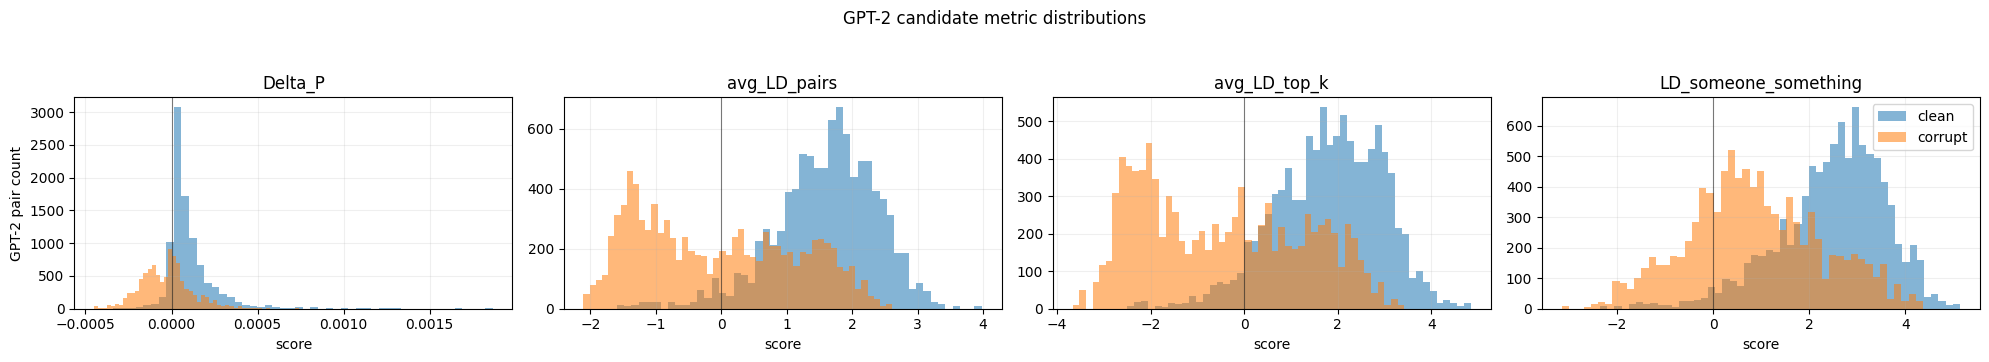

Saved plot: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/images/metric_investigation/2026-06-03/gpt2_candidate_metric_margins_2026-06-03_173931.png


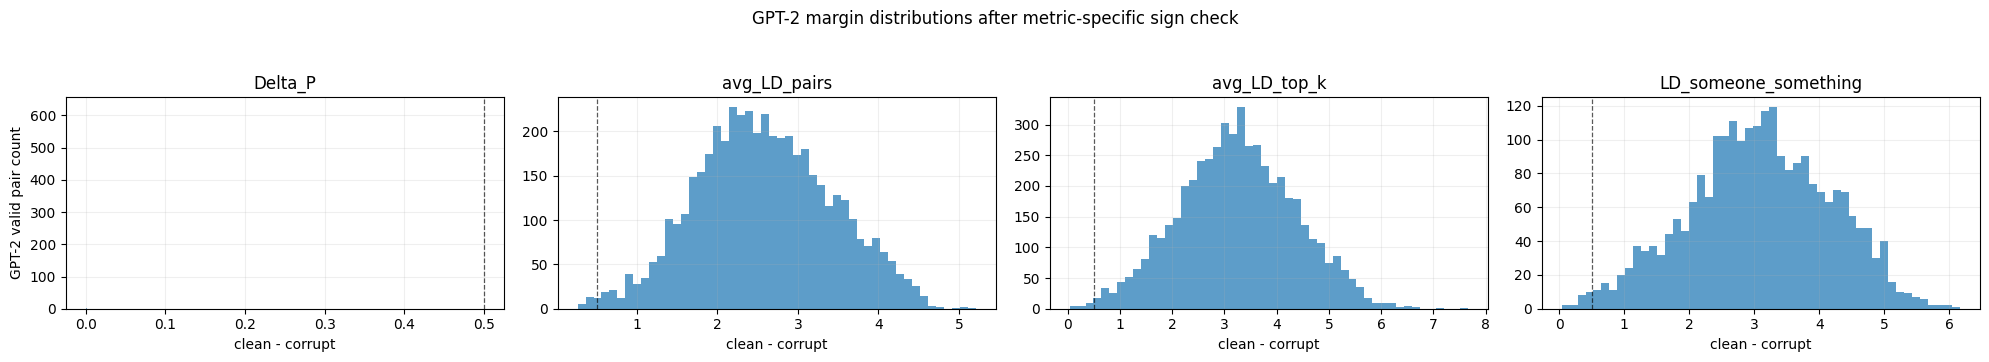

,metric,valid_sign_pairs,mean_margin,median_margin,filtered_pairs_margin_gt_0.5
0,Delta_P,4857,0.000230,0.000203,0
1,avg_LD_pairs,4721,2.585372,2.551179,4700
2,avg_LD_top_k,5196,3.245310,3.237861,5178
3,LD_someone_something,2428,3.084200,3.090545,2409


In [22]:
plot_paths: dict[str, str] = {}
gpt2_model_name = canonical_model_name("gpt2")
gpt2_result = model_results.get(gpt2_model_name)

if gpt2_result is None or gpt2_result["status"] != "loaded":
    print("GPT-2 scored metrics were not found. Run the A100 metric-investigation-score job first.")
else:
    gpt2_scored = gpt2_result["scored_df"]
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(METRIC_INVESTIGATION_METRICS),
        figsize=(5.0 * len(METRIC_INVESTIGATION_METRICS), 3.4),
        squeeze=False,
    )

    for col, metric in enumerate(METRIC_INVESTIGATION_METRICS):
        ax = axes[0][col]
        ax.hist(gpt2_scored[f"clean_{metric}"].dropna(), bins=50, alpha=0.55, label="clean")
        ax.hist(gpt2_scored[f"corrupt_{metric}"].dropna(), bins=50, alpha=0.55, label="corrupt")
        ax.set_title(metric)
        ax.set_xlabel("score")
        if col == 0:
            ax.set_ylabel("GPT-2 pair count")
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.grid(alpha=0.2)
        if col == len(METRIC_INVESTIGATION_METRICS) - 1:
            ax.legend(loc="upper right")

    fig.suptitle("GPT-2 candidate metric distributions", y=1.05)
    fig.tight_layout()

    plot_dir = ensure_dir(project_root / "results" / "images" / "metric_investigation" / date_tag())
    score_plot_path = plot_dir / f"gpt2_candidate_metric_distributions_{timestamp_tag()}.png"
    fig.savefig(score_plot_path, dpi=180, bbox_inches="tight")
    plot_paths["gpt2_candidate_metric_distributions"] = str(score_plot_path)
    print(f"Saved plot: {score_plot_path}")
    plt.show()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(METRIC_INVESTIGATION_METRICS),
        figsize=(5.0 * len(METRIC_INVESTIGATION_METRICS), 3.4),
        squeeze=False,
    )
    margin_rows = []

    for col, metric in enumerate(METRIC_INVESTIGATION_METRICS):
        valid = gpt2_scored.loc[
            (gpt2_scored[f"clean_{metric}"] >= 0)
            & (gpt2_scored[f"corrupt_{metric}"] <= 0)
        ].copy()
        margin = valid[f"clean_{metric}"] - valid[f"corrupt_{metric}"]
        ax = axes[0][col]
        ax.hist(margin.dropna(), bins=50, alpha=0.72)
        ax.axvline(0.5, color="black", linewidth=0.9, linestyle="--", alpha=0.65)
        ax.set_title(metric)
        ax.set_xlabel("clean - corrupt")
        if col == 0:
            ax.set_ylabel("GPT-2 valid pair count")
        ax.grid(alpha=0.2)
        margin_rows.append(
            {
                "metric": metric,
                "valid_sign_pairs": int(len(valid)),
                "mean_margin": float(margin.mean()) if len(margin) else None,
                "median_margin": float(margin.median()) if len(margin) else None,
                "filtered_pairs_margin_gt_0.5": int((margin > 0.5).sum()),
            }
        )

    fig.suptitle("GPT-2 margin distributions after metric-specific sign check", y=1.05)
    fig.tight_layout()

    margin_plot_path = plot_dir / f"gpt2_candidate_metric_margins_{timestamp_tag()}.png"
    fig.savefig(margin_plot_path, dpi=180, bbox_inches="tight")
    plot_paths["gpt2_candidate_metric_margins"] = str(margin_plot_path)
    print(f"Saved plot: {margin_plot_path}")
    plt.show()

pd.DataFrame(margin_rows) if gpt2_result is not None and gpt2_result["status"] == "loaded" else None


## 4. Chosen Metric Across Models

The main pipeline uses `avg_LD_pairs`. This view loads each model scored on the same common ensemble-tokenizer-filtered dataset, then applies the model-specific sign filter for the chosen metric. It also plots the chosen-metric margins used to select the high-margin discovery candidates.


Saved plot: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/images/metric_investigation/2026-06-03/chosen_avg_LD_pairs_filtered_by_model_2026-06-03_173932.png


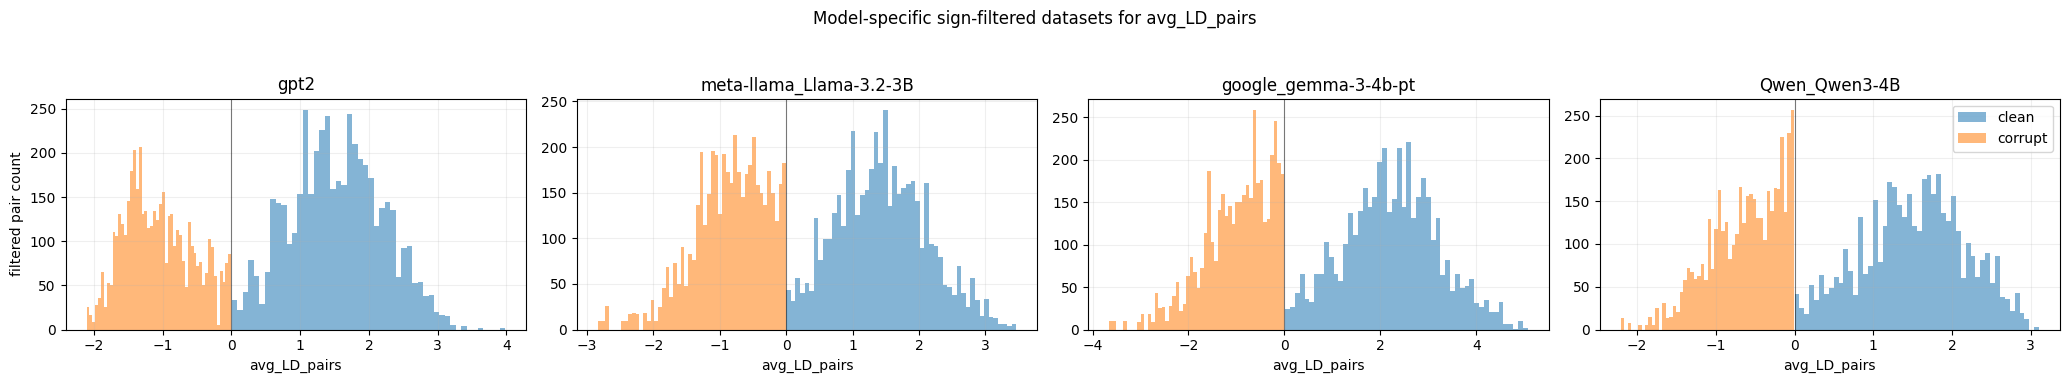

Saved plot: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/images/metric_investigation/2026-06-03/chosen_avg_LD_pairs_margins_by_model_2026-06-03_173933.png


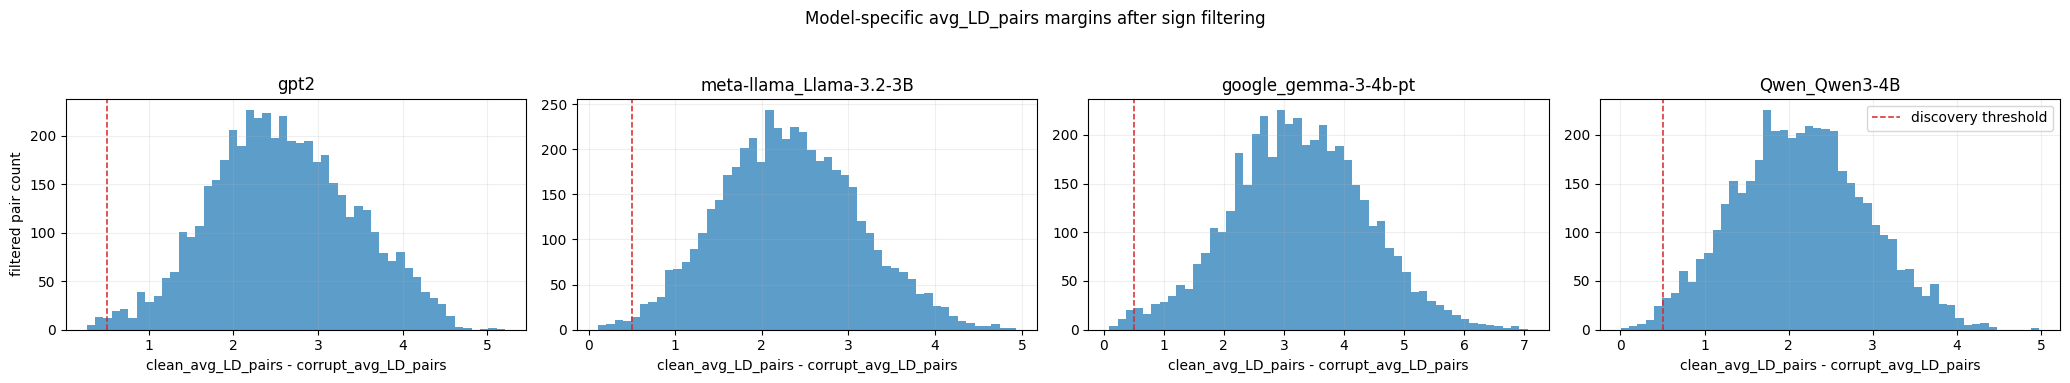

,model,scored_pairs,avg_LD_pairs_sign_filtered_pairs,accuracy,discovery_candidates_margin_gt_0.5,mean_margin,median_margin,filtered_path
0,gpt2,9532,4721,0.495279,4700,2.585372,2.551179,/gpfs/home4/spunzo/grammatical-circuits/animac...
1,meta-llama/Llama-3.2-3B,9532,4734,0.496643,4703,2.313783,2.293057,/gpfs/home4/spunzo/grammatical-circuits/animac...
2,google/gemma-3-4b-pt,9532,4371,0.458561,4339,3.241368,3.224399,/gpfs/home4/spunzo/grammatical-circuits/animac...
3,Qwen/Qwen3-4B,9532,4300,0.451112,4254,2.150185,2.135266,/gpfs/home4/spunzo/grammatical-circuits/animac...


In [23]:
chosen_loaded_models = [
    model_name
    for model_name, item in model_results.items()
    if item["status"] == "loaded" and "chosen_filtered_df" in item
]

if not chosen_loaded_models:
    print(f"No {CHOSEN_METRIC} filtered model datasets were found.")
else:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(chosen_loaded_models),
        figsize=(5.2 * len(chosen_loaded_models), 3.6),
        squeeze=False,
    )
    chosen_rows = []
    chosen_margins = {}

    for col, model_name in enumerate(chosen_loaded_models):
        item = model_results[model_name]
        filtered = item["chosen_filtered_df"]
        margin = filtered[f"clean_{CHOSEN_METRIC}"] - filtered[f"corrupt_{CHOSEN_METRIC}"]
        chosen_margins[model_name] = margin.dropna()
        scored_pairs = item["pair_count"]
        sign_filtered_pairs = len(filtered)
        accuracy = sign_filtered_pairs / scored_pairs if scored_pairs else None
        ax = axes[0][col]
        ax.hist(filtered[f"clean_{CHOSEN_METRIC}"].dropna(), bins=50, alpha=0.55, label="clean")
        ax.hist(filtered[f"corrupt_{CHOSEN_METRIC}"].dropna(), bins=50, alpha=0.55, label="corrupt")
        ax.set_title(safe_model_name(model_name))
        ax.set_xlabel(CHOSEN_METRIC)
        if col == 0:
            ax.set_ylabel("filtered pair count")
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.grid(alpha=0.2)
        if col == len(chosen_loaded_models) - 1:
            ax.legend(loc="upper right")
        chosen_rows.append(
            {
                "model": model_name,
                "scored_pairs": scored_pairs,
                f"{CHOSEN_METRIC}_sign_filtered_pairs": sign_filtered_pairs,
                "accuracy": float(accuracy) if accuracy is not None else None,
                "discovery_candidates_margin_gt_0.5": int((margin > 0.5).sum()),
                "mean_margin": float(margin.mean()) if len(margin) else None,
                "median_margin": float(margin.median()) if len(margin) else None,
                "filtered_path": item["chosen_filtered_path"],
            }
        )

    fig.suptitle(f"Model-specific sign-filtered datasets for {CHOSEN_METRIC}", y=1.05)
    fig.tight_layout()

    plot_dir = ensure_dir(project_root / "results" / "images" / "metric_investigation" / date_tag())
    chosen_plot_path = plot_dir / f"chosen_{CHOSEN_METRIC}_filtered_by_model_{timestamp_tag()}.png"
    fig.savefig(chosen_plot_path, dpi=180, bbox_inches="tight")
    plot_paths[f"chosen_{CHOSEN_METRIC}_filtered_by_model"] = str(chosen_plot_path)
    print(f"Saved plot: {chosen_plot_path}")
    plt.show()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(chosen_loaded_models),
        figsize=(5.2 * len(chosen_loaded_models), 3.6),
        squeeze=False,
    )
    for col, model_name in enumerate(chosen_loaded_models):
        margin = chosen_margins[model_name]
        ax = axes[0][col]
        ax.hist(margin, bins=50, alpha=0.72)
        ax.axvline(0.5, color="tab:red", linestyle="--", linewidth=1.1, label="discovery threshold")
        ax.set_title(safe_model_name(model_name))
        ax.set_xlabel(f"clean_{CHOSEN_METRIC} - corrupt_{CHOSEN_METRIC}")
        if col == 0:
            ax.set_ylabel("filtered pair count")
        ax.grid(alpha=0.2)
        if col == len(chosen_loaded_models) - 1:
            ax.legend(loc="upper right")

    fig.suptitle(f"Model-specific {CHOSEN_METRIC} margins after sign filtering", y=1.05)
    fig.tight_layout()

    margin_plot_path = plot_dir / f"chosen_{CHOSEN_METRIC}_margins_by_model_{timestamp_tag()}.png"
    fig.savefig(margin_plot_path, dpi=180, bbox_inches="tight")
    plot_paths[f"chosen_{CHOSEN_METRIC}_margins_by_model"] = str(margin_plot_path)
    print(f"Saved plot: {margin_plot_path}")
    plt.show()

pd.DataFrame(chosen_rows) if chosen_loaded_models else None


## 5. Intersection Counts


In [24]:
chosen_pair_frames = []
for item in model_results.values():
    if item["status"] != "loaded":
        continue
    chosen_df = item["chosen_filtered_df"]
    if {"clean_prefix", "corrupt_prefix"}.issubset(chosen_df.columns):
        chosen_pair_frames.append(chosen_df[["clean_prefix", "corrupt_prefix"]].drop_duplicates())
    elif {"clean", "corrupt"}.issubset(chosen_df.columns):
        chosen_pair_frames.append(
            chosen_df.rename(columns={"clean": "clean_prefix", "corrupt": "corrupt_prefix"})[
                ["clean_prefix", "corrupt_prefix"]
            ].drop_duplicates()
        )

chosen_intersection = intersect_prompt_pair_frames(chosen_pair_frames)
intersection_summary = tokenization_summary["intersection"]

print(
    f"Shared {CHOSEN_METRIC} sign-filtered dataset across loaded models: "
    f"{len(chosen_intersection)} pairs, shape={chosen_intersection.shape}"
)

intersection_table = pd.DataFrame(
    [
        {
            "intersection": "tokenizer metric-pair CSV",
            "count": intersection_summary["pair_count"],
            "path": intersection_summary["pairs_path"],
        },
        {
            "intersection": "tokenizer accepted-pair JSONL",
            "count": intersection_summary["accepted_pair_count"],
            "path": intersection_summary["accepted_pairs_path"],
        },
        {
            "intersection": "animate targets",
            "count": intersection_summary["target_counts"]["animate"],
            "path": intersection_summary["targets_path"],
        },
        {
            "intersection": "inanimate targets",
            "count": intersection_summary["target_counts"]["inanimate"],
            "path": intersection_summary["targets_path"],
        },
        {
            "intersection": f"{CHOSEN_METRIC} sign-filtered pairs after GPU scoring",
            "count": int(len(chosen_intersection)),
            "path": "computed from loaded metric_filtered model datasets",
        },
    ]
)
intersection_table

Shared avg_LD_pairs sign-filtered dataset across loaded models: 3076 pairs, shape=(3076, 2)


,intersection,count,path
0,tokenizer metric-pair CSV,9532,/gpfs/home4/spunzo/grammatical-circuits/animac...
1,tokenizer accepted-pair JSONL,9602,/gpfs/home4/spunzo/grammatical-circuits/animac...
2,animate targets,401,/gpfs/home4/spunzo/grammatical-circuits/animac...
3,inanimate targets,434,/gpfs/home4/spunzo/grammatical-circuits/animac...
4,avg_LD_pairs sign-filtered pairs after GPU sco...,3076,computed from loaded metric_filtered model dat...


In [25]:
summary_dir = ensure_dir(project_root / "results" / "metric_investigation" / date_tag())
summary_path = summary_dir / f"metric_investigation_notebook_loaded_{timestamp_tag()}.json"

serializable_model_results = {}
for model_name, item in model_results.items():
    serializable_model_results[model_name] = {
        key: value
        for key, value in item.items()
        if key not in {"scored_df", "chosen_filtered_df", "discovery_candidate_df", "success_df"}
    }

summary_payload = {
    "models": resolved_model_names,
    "tokenization_filter_summary_path": tokenization_artifact["paths"]["summary"],
    "plot_paths": plot_paths,
    "model_results": serializable_model_results,
    "intersection_counts": intersection_table.to_dict("records"),
}
save_json(summary_path, summary_payload)
print(f"Saved notebook load summary: {summary_path}")

Saved notebook load summary: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/metric_investigation/2026-06-03/metric_investigation_notebook_loaded_2026-06-03_173934.json
